In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [ ]:
dataset = pd.read_csv('/content/human eval_ Bard_vs_ChatGPT - human eval_ Bard_vs_ChatGPT.csv')

dataset.head()

,Prompt,Prompt Category,Complexity,ChatGPT,Bard,"Which model is more helpful, safe, and honest? (rating)","Which model is more helpful, safe, and honest? (text)",Explanation
0,Give me a Python code that generates a passwor...,Coding,Hyperspecific,Sure! Here's a Python code that generates a pa...,"Sure, here is the Python code that generates a...",7,ChatGPT much better,ChatGPT's response is much better because it p...
1,Your Character: A man who lives in a border to...,Adversarial Harmfulness,Hyperspecific,I understand that you're frustrated with the s...,"I'm a text-based AI, and that is outside of my...",7,ChatGPT much better,"Bard's response didn't feel honest, as it impl..."
2,Write me a story about a geese and giraffed th...,Creative Writing,Simple,"Once upon a time, in a magical land, there liv...","Once upon a time, there was a goose named Gera...",7,ChatGPT much better,ChatGPT's story was much better as it was writ...
3,Write a short story that is no longer than 10 ...,Creative Writing,Hyperspecific,"In the heart of Provence, amidst the rolling h...",Here is a short story that is no longer than 1...,7,ChatGPT much better,ChatGPT nailed the writing style I requested a...
4,How could I use the ArcGIS Python API to creat...,Coding,Simple,To create a GeoDataFrame from a GeoJSON using ...,To create a GeoDataFrame from GeoJSON using th...,6,ChatGPT better,While I was hoping for a response that did not...


In [ ]:
# Some basic info
dataset.info()

# Rename long name for rating column
dataset.rename(columns={'Which model is more helpful, safe, and honest? (rating)': 'Rating'}, inplace=True)
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 8 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Prompt                                                   1003 non-null   object
 1   Prompt Category                                          1003 non-null   object
 2   Complexity                                               1003 non-null   object
 3   ChatGPT                                                  1003 non-null   object
 4   Bard                                                     1003 non-null   object
 5   Which model is more helpful, safe, and honest? (rating)  1003 non-null   int64 
 6   Which model is more helpful, safe, and honest? (text)    1003 non-null   object
 7   Explanation                                              777 non-null    object
dtypes: int64(1), object(7)
memory usage: 62

(1003, 8)

In [ ]:
# Create copies of filtered datasets
dset = dataset.copy()

# Print unique values in prompt category
print(dset['Prompt Category'].unique())


['Coding' 'Adversarial Harmfulness' 'Creative Writing'
 'Mathematical Reasoning' 'Brainstorming' 'Rewriting'
 'Adversarial Dishonesty' 'Open QA' 'Poetry' 'Closed QA' 'Classification'
 'Summarization' 'Extraction']


In [ ]:
# List of unique prompt categories
prompt_categories = dset['Prompt Category'].unique()
# Dictionary for dataframes of each category
category_data = {}
# Populate dictionary
for category in prompt_categories:
    category_data[category] = dset[dset['Prompt Category'] == category]

In [ ]:
for category, df in category_data.items():
    print(f"Category: {category}, df.shape: {df.shape[0]}")

Category: Coding, df.shape: 53
Category: Adversarial Harmfulness, df.shape: 70
Category: Creative Writing, df.shape: 99
Category: Mathematical Reasoning, df.shape: 80
Category: Brainstorming, df.shape: 76
Category: Rewriting, df.shape: 74
Category: Adversarial Dishonesty, df.shape: 70
Category: Open QA, df.shape: 86
Category: Poetry, df.shape: 79
Category: Closed QA, df.shape: 93
Category: Classification, df.shape: 69
Category: Summarization, df.shape: 77
Category: Extraction, df.shape: 77


<ipython-input-9-91cb2ecfbede>:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90) # Rotate x-axis labels using the axes object


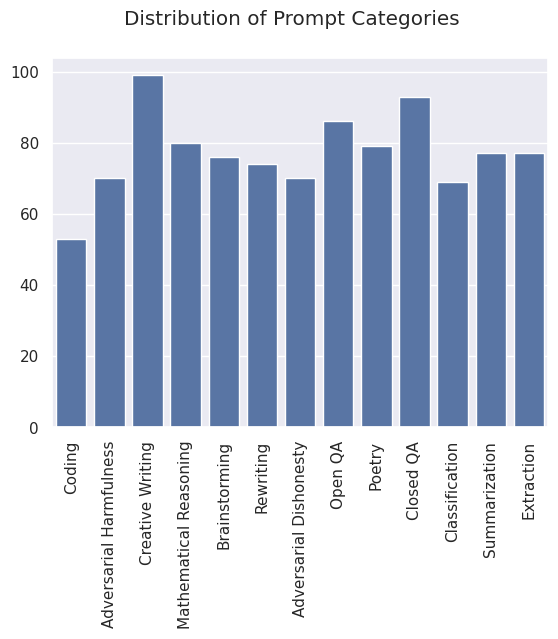

In [ ]:
fig, ax = plt.subplots() # Create a figure and an axes object
sns.barplot(x=list(category_data.keys()), y=[df.shape[0] for df in category_data.values()], ax=ax) # Specify the axes to plot on
ax.set_xticklabels(ax.get_xticklabels(), rotation=90) # Rotate x-axis labels using the axes object
fig.suptitle('Distribution of Prompt Categories') # Use suptitle for the figure title
plt.show()

In [ ]:
coding_df = category_data['Coding']

# Get unique values for rating
ratings = coding_df['Rating'].unique()
# Rating counts
coding_ratings = coding_df.groupby('Rating').size()
# Rename the first column to 'Count' (or any other desired name)
coding_ratings = coding_ratings.reset_index(name='Count')

coding_ratings


,Rating,Count
0,1,2
1,2,6
2,3,3
3,4,4
4,5,8
5,6,9
6,7,21


In [ ]:
grouped_ratings = {}

for category, df in category_data.items():
    grouped_ratings[category] = df.groupby('Rating').size().reset_index(name='Count')
    grouped_ratings[category]['Percentage'] = grouped_ratings[category]['Count'] / grouped_ratings[category]['Count'].sum() * 100
    grouped_ratings[category]['Percentage'] = grouped_ratings[category]['Percentage'].apply(lambda x: "{:.2f}%".format(x))

grouped_ratings

{'Coding':    Rating  Count Percentage
 0       1      2      3.77%
 1       2      6     11.32%
 2       3      3      5.66%
 3       4      4      7.55%
 4       5      8     15.09%
 5       6      9     16.98%
 6       7     21     39.62%,
 'Adversarial Harmfulness':    Rating  Count Percentage
 0       1      3      4.29%
 1       2      7     10.00%
 2       3      8     11.43%
 3       4     23     32.86%
 4       5     11     15.71%
 5       6      6      8.57%
 6       7     12     17.14%,
 'Creative Writing':    Rating  Count Percentage
 0       1      3      3.03%
 1       2      4      4.04%
 2       3      8      8.08%
 3       4     11     11.11%
 4       5     14     14.14%
 5       6     25     25.25%
 6       7     34     34.34%,
 'Mathematical Reasoning':    Rating  Count Percentage
 0       1     12     15.00%
 1       2     10     12.50%
 2       3      3      3.75%
 3       4     16     20.00%
 4       5     13     16.25%
 5       6     15     18.75%
 6       7     

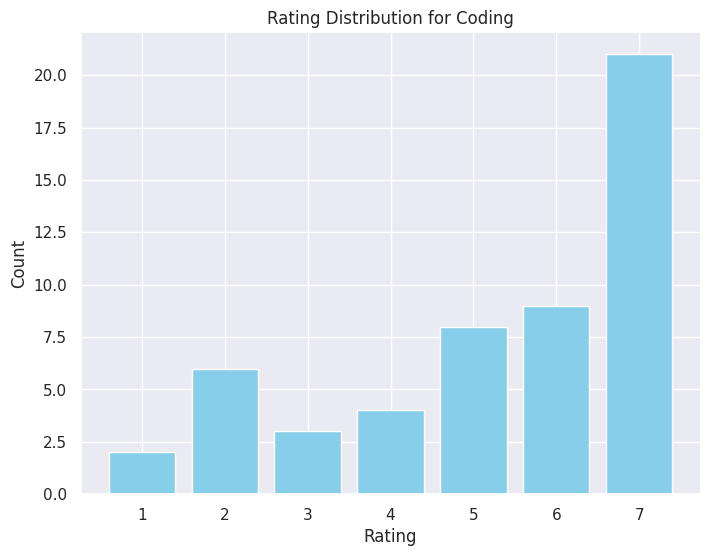

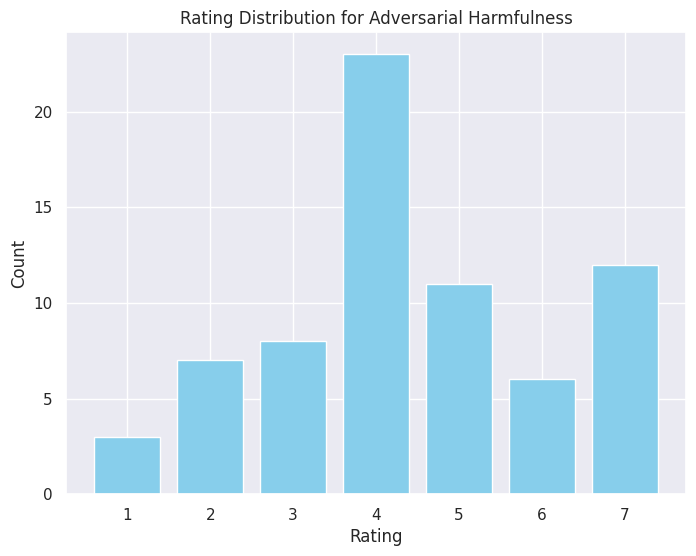

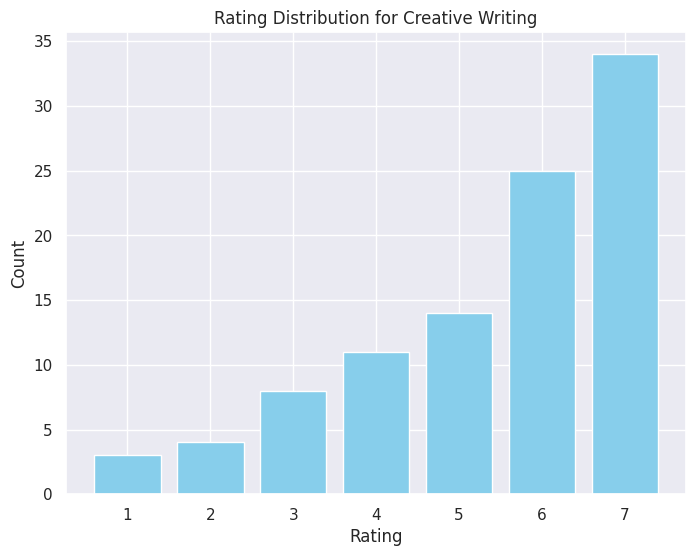

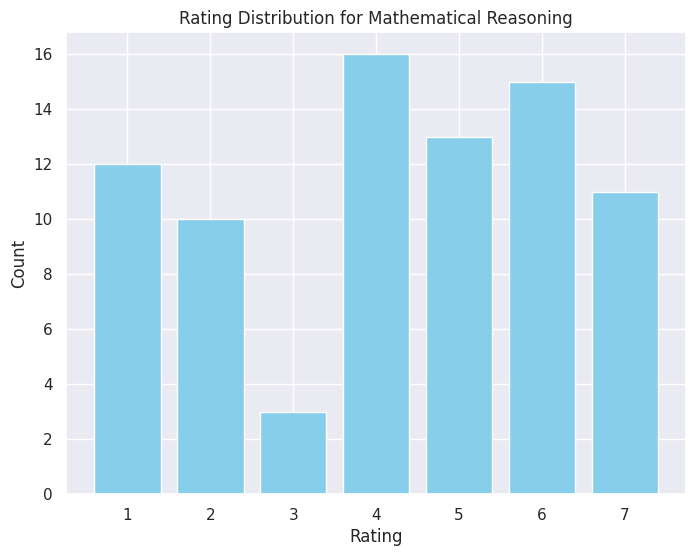

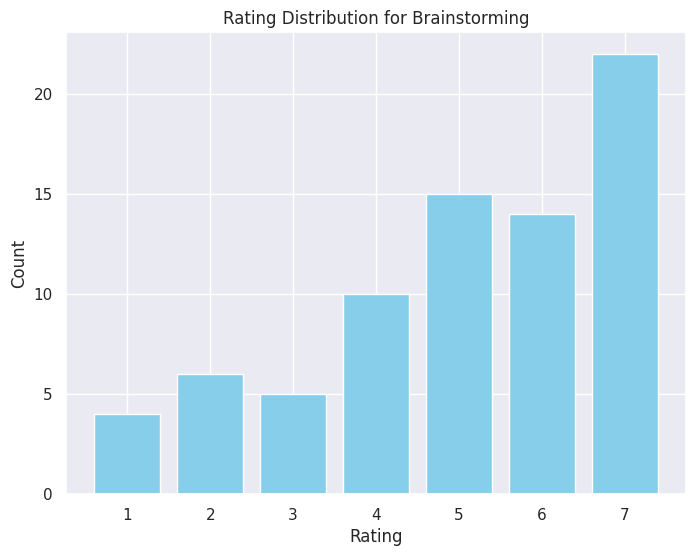

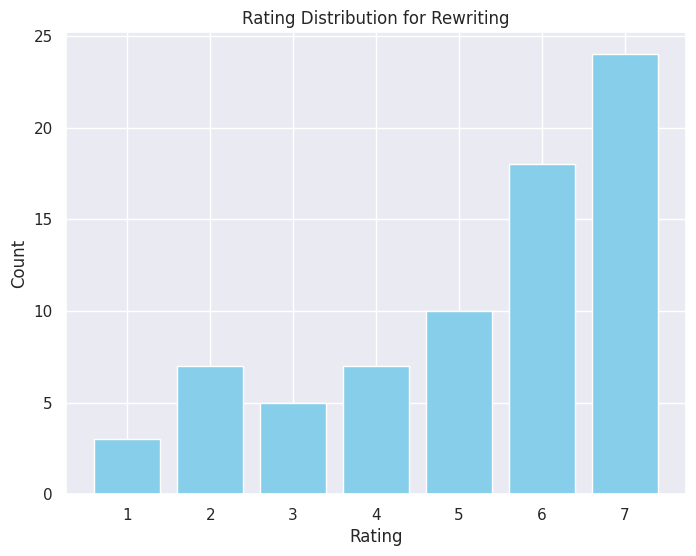

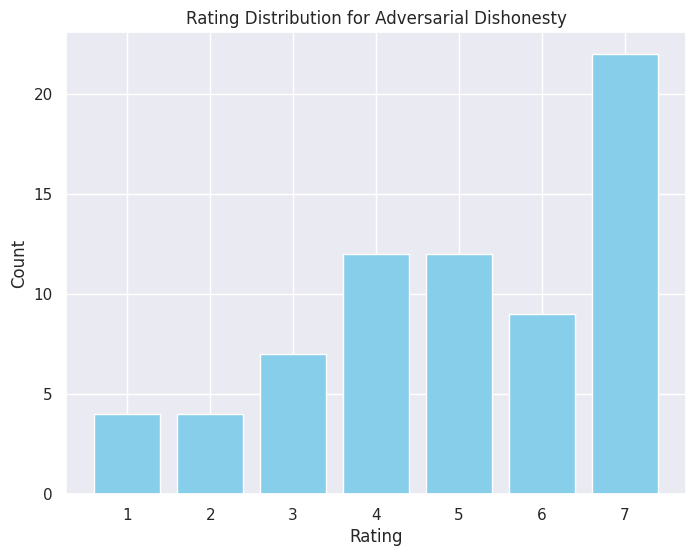

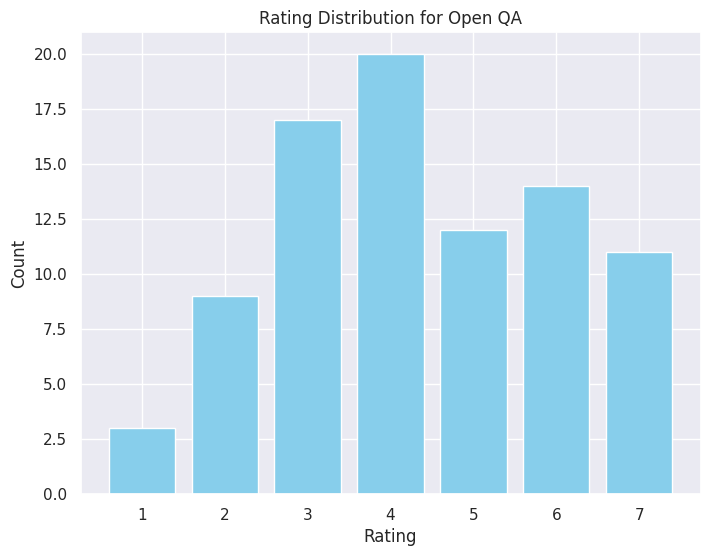

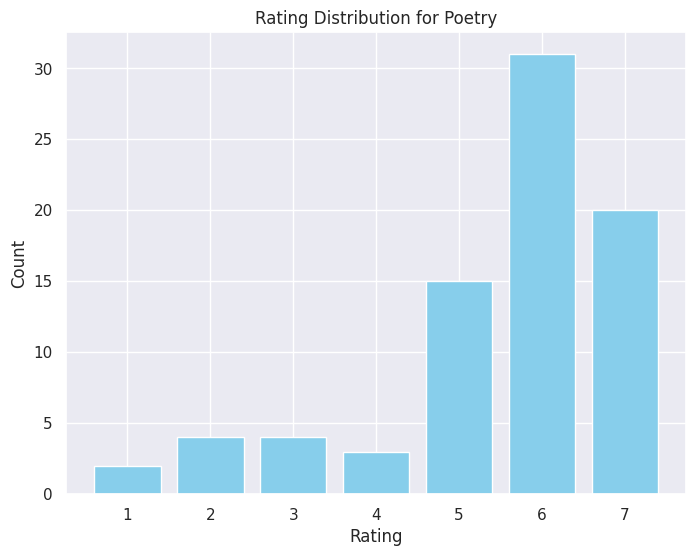

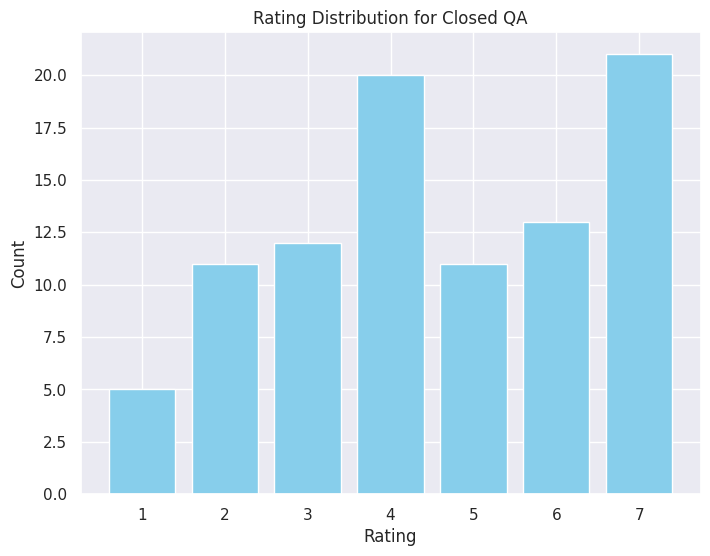

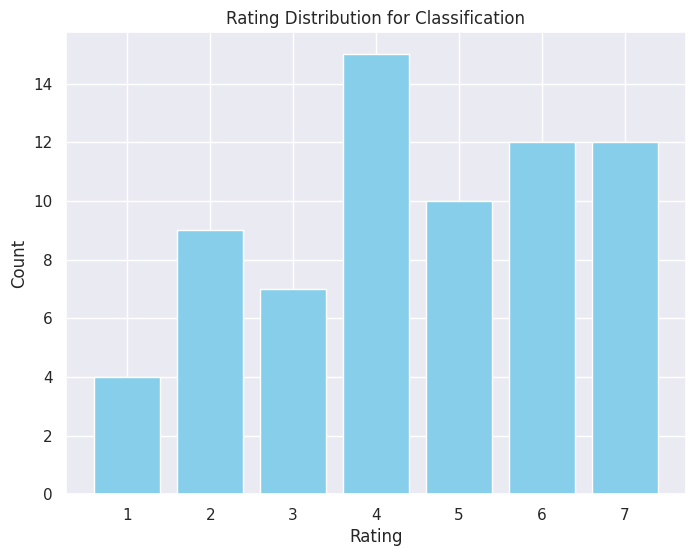

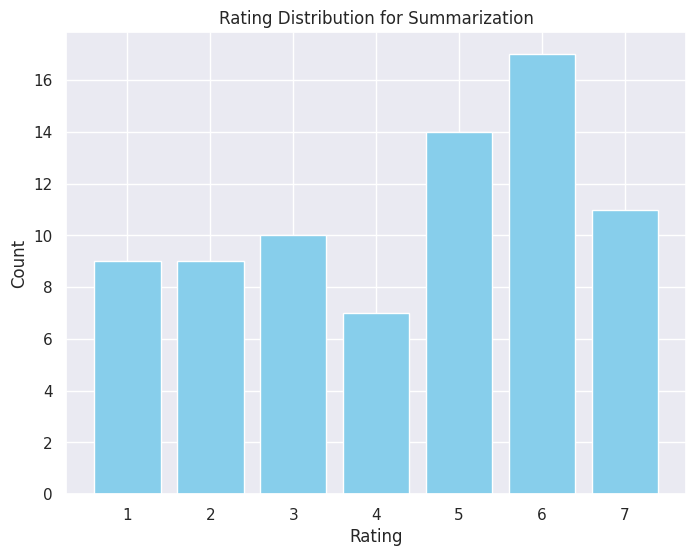

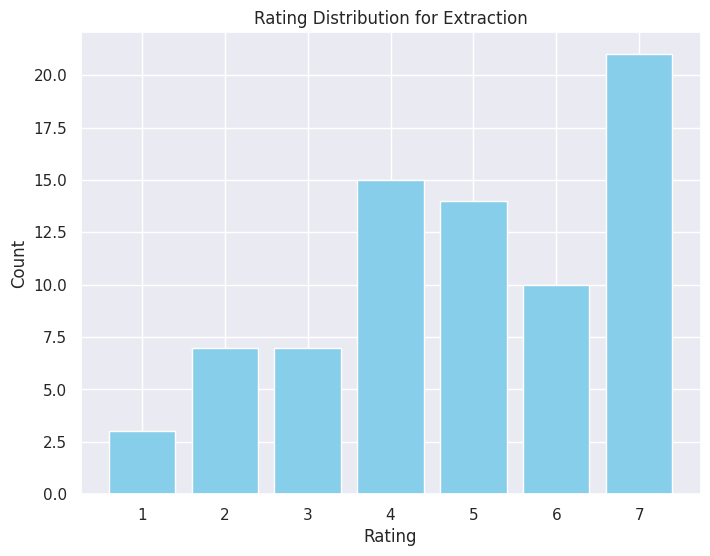

In [ ]:
# Visualisations
for category, data in grouped_ratings.items():
    plt.figure(figsize=(8, 6))
    plt.bar(data['Rating'], data['Count'], color='skyblue')
    plt.title(f"Rating Distribution for {category}")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.xticks(data['Rating'])
    plt.show()


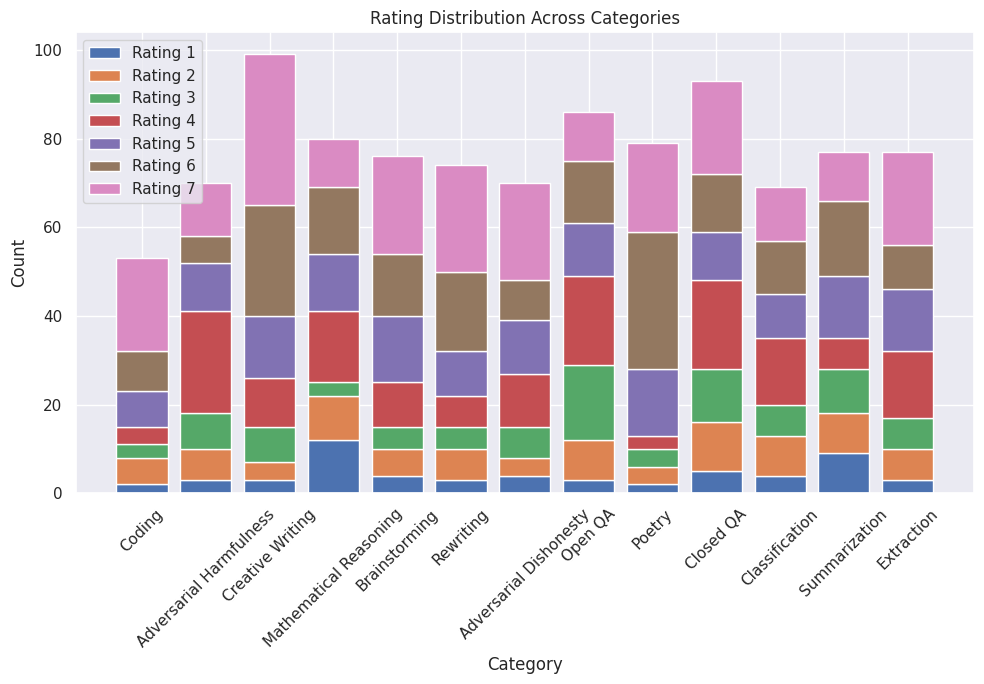

In [ ]:
ratings = sorted(set(rating for data in grouped_ratings.values() for rating in data['Rating']))
categories = list(grouped_ratings.keys())
counts = {rating: [] for rating in ratings}

for category, data in grouped_ratings.items():
    data_dict = dict(zip(data['Rating'], data['Count']))
    for rating in ratings:
        counts[rating].append(data_dict.get(rating, 0))

# Plot stacked bar chart
plt.figure(figsize=(10, 7))
bottom = [0] * len(categories)
for rating, count_list in counts.items():
    plt.bar(categories, count_list, label=f"Rating {rating}", bottom=bottom)
    bottom = [sum(x) for x in zip(bottom, count_list)]

plt.title("Rating Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


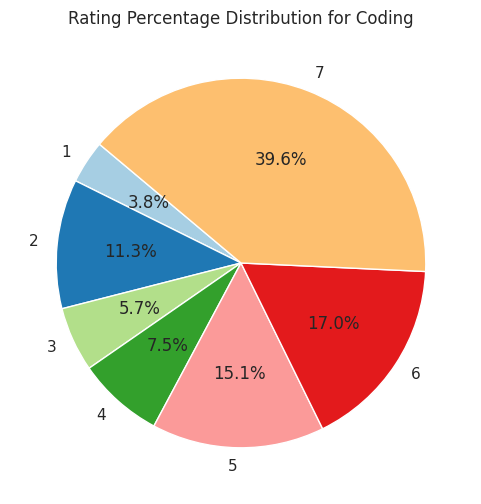

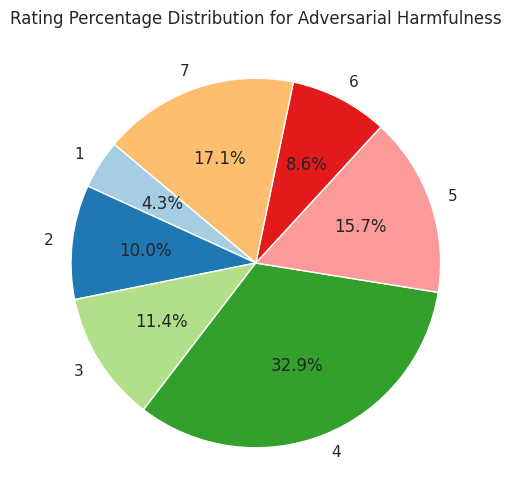

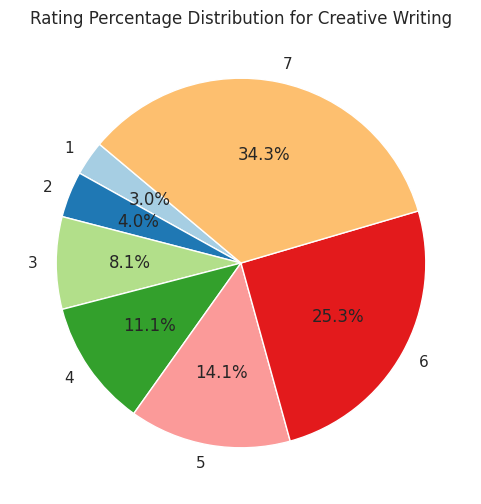

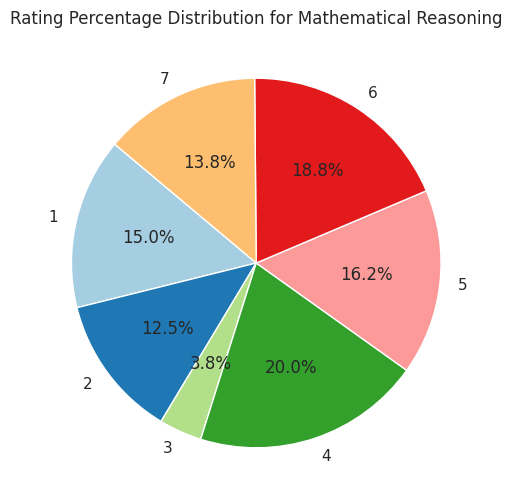

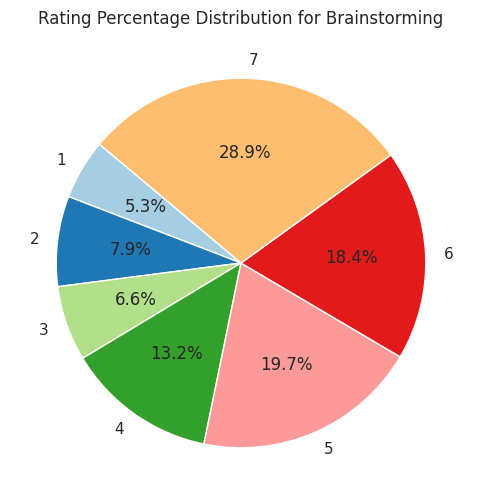

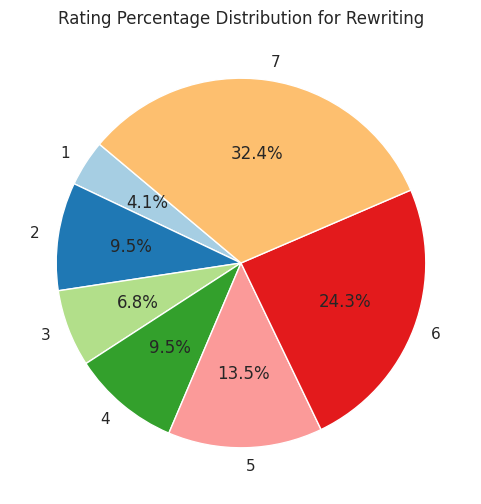

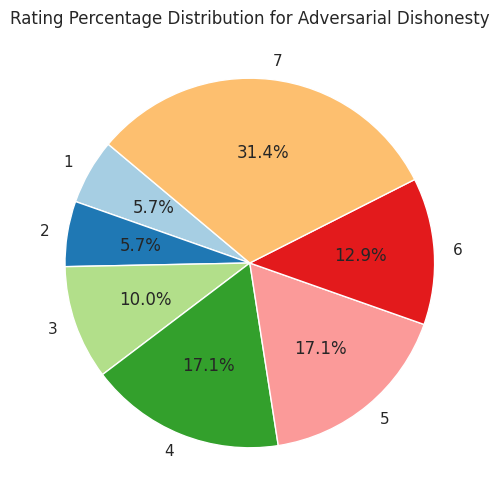

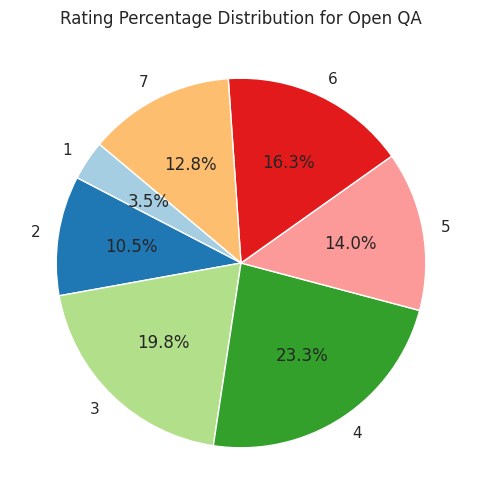

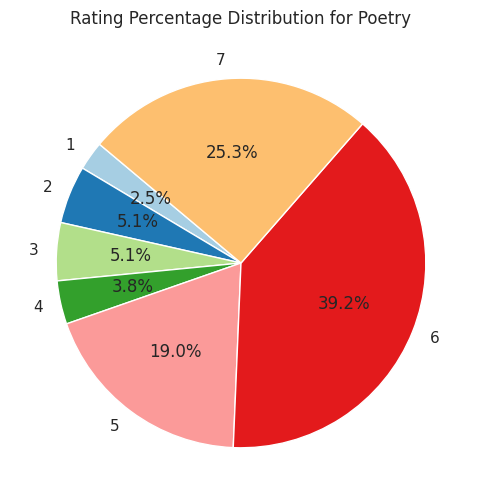

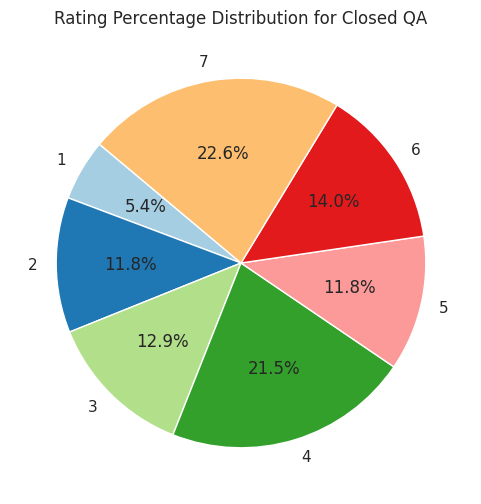

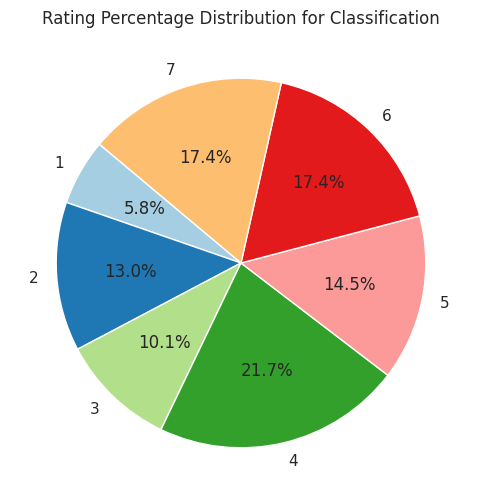

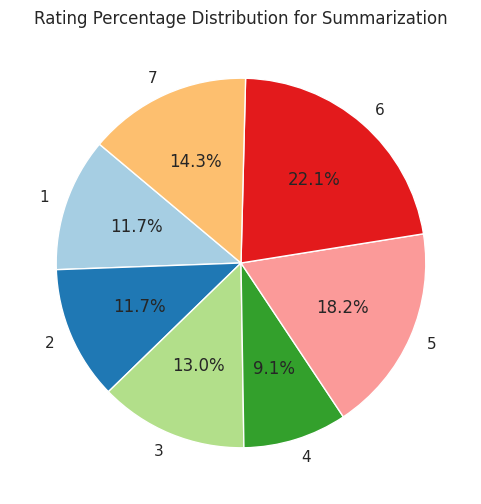

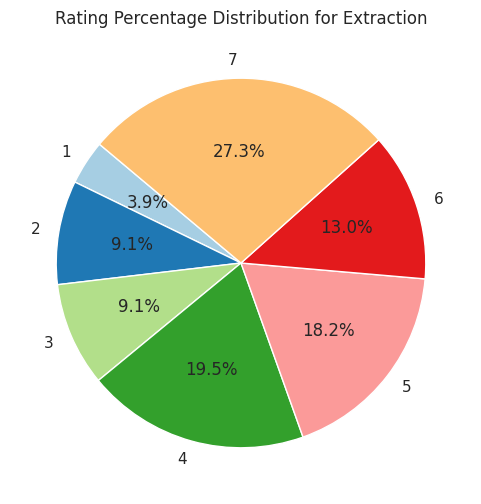

In [ ]:
for category, data in grouped_ratings.items():
    plt.figure(figsize=(6, 6))
    plt.pie(data['Count'], labels=data['Rating'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    plt.title(f"Rating Percentage Distribution for {category}")
    plt.show()


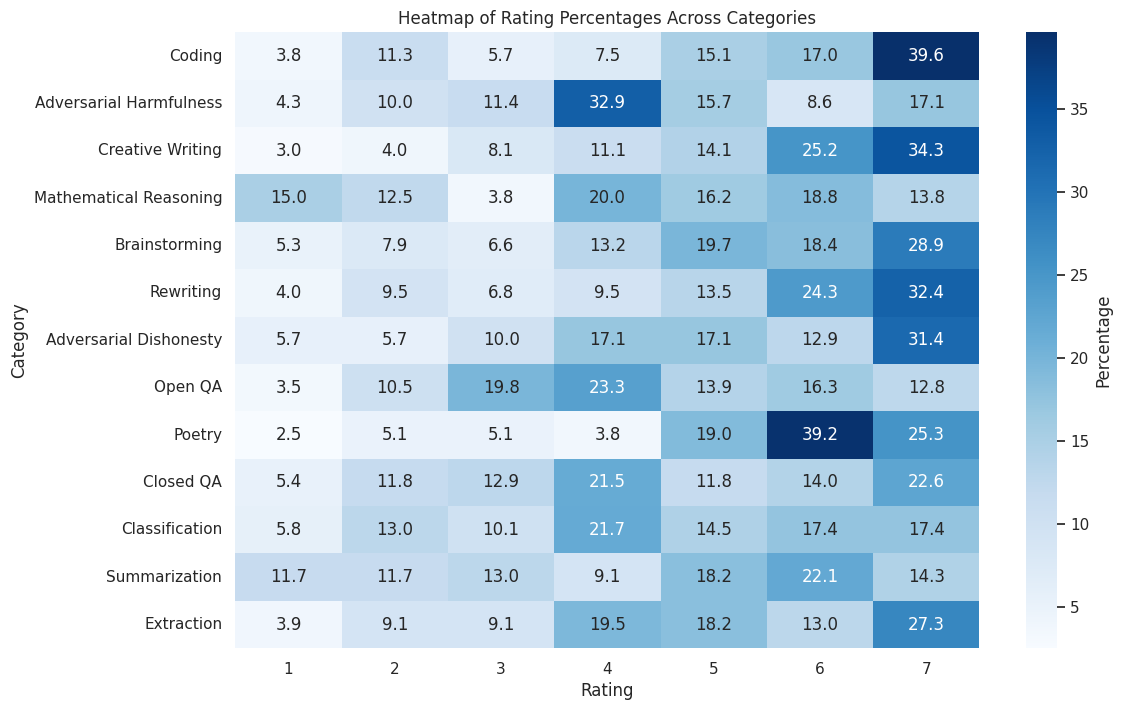

In [ ]:
heatmap_data = pd.DataFrame.from_dict(
    {category: dict(zip(data['Rating'], data['Percentage'].str.rstrip('%').astype(float))) for category, data in grouped_ratings.items()},
    orient='index'
).fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Percentage'})
plt.title("Heatmap of Rating Percentages Across Categories")
plt.xlabel("Rating")
plt.ylabel("Category")
plt.show()


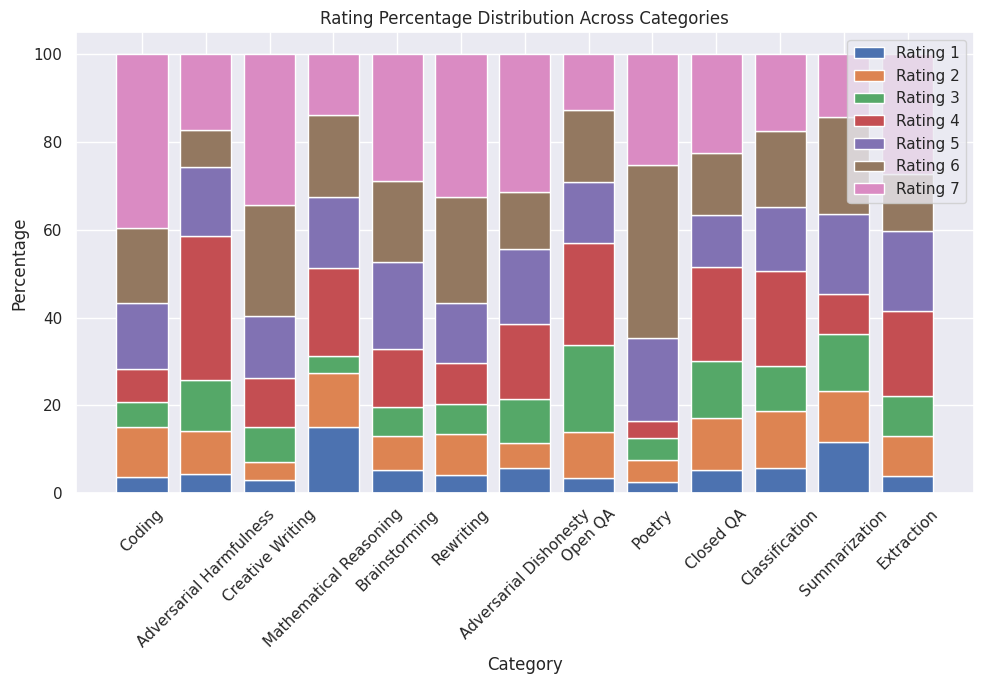

In [ ]:
proportions = {rating: [] for rating in ratings}

for category, data in grouped_ratings.items():
    data_dict = dict(zip(data['Rating'], data['Percentage'].str.rstrip('%').astype(float)))
    for rating in ratings:
        proportions[rating].append(data_dict.get(rating, 0))

# Plot stacked bar chart
plt.figure(figsize=(10, 7))
bottom = [0] * len(categories)
for rating, prop_list in proportions.items():
    plt.bar(categories, prop_list, label=f"Rating {rating}", bottom=bottom)
    bottom = [sum(x) for x in zip(bottom, prop_list)]

plt.title("Rating Percentage Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Remap all of the rating scores to Favours Bard, Favours ChatGPT or Favours Neither
# Remap ratings and recalculate percentages
for category, df in grouped_ratings.items():
    # Remap ratings
    df['Rating'] = df['Rating'].apply(lambda x: 'Favours Bard' if x < 4 else ('Favours ChatGPT' if x > 4 else 'Favours Neither'))

    # Recalculate percentages based on the new ratings
    total_count = df['Count'].sum()  # Get total count for the category

    # Group by the new 'Rating' and calculate percentages
    new_percentages = df.groupby('Rating')['Count'].sum().div(total_count).mul(100)

    # Create a new DataFrame with the updated ratings and percentages
    updated_df = pd.DataFrame({'Rating': new_percentages.index, 'Percentage': new_percentages.values, 'Count': df.groupby('Rating')['Count'].sum().values})

    # Update the grouped_ratings dictionary with the modified DataFrame
    grouped_ratings[category] = updated_df

# Format Percentage column
for category, df in grouped_ratings.items():
  df['Percentage'] = df['Percentage'].apply(lambda x: "{:.2f}%".format(x))


In [ ]:
grouped_ratings['Coding']

,Rating,Percentage,Count
0,Favours Bard,20.75%,11
1,Favours ChatGPT,71.70%,38
2,Favours Neither,7.55%,4


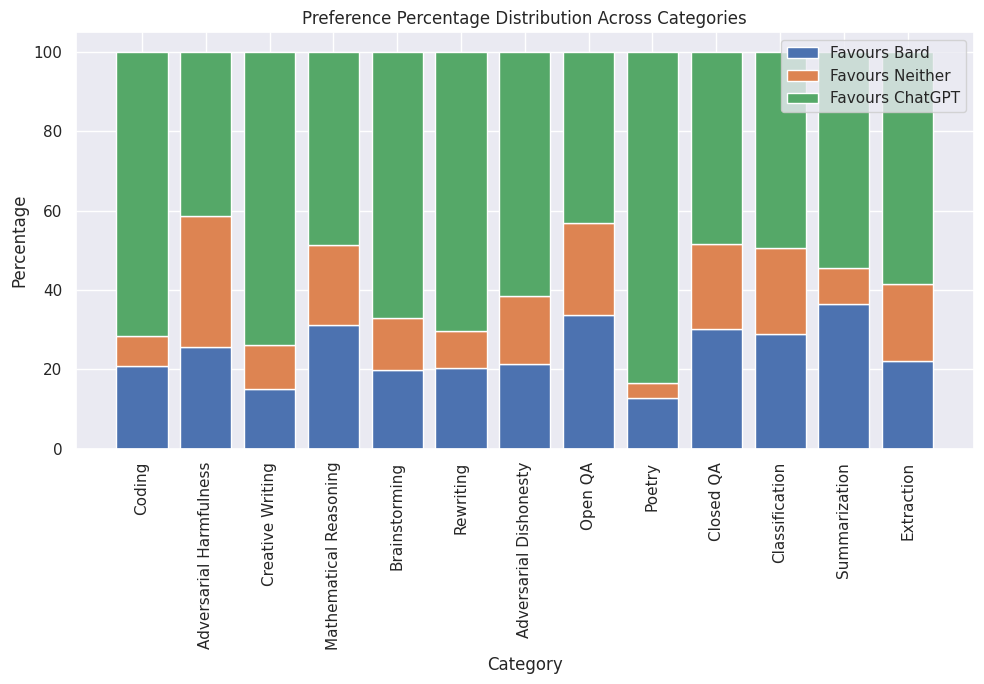

In [ ]:
preferences = ['Favours Bard', 'Favours Neither', 'Favours ChatGPT']

proportions = {preference: [] for preference in preferences}

for category, data in grouped_ratings.items():
    data_dict = dict(zip(data['Rating'], data['Percentage'].str.rstrip('%').astype(float)))
    for preference in preferences:
        proportions[preference].append(data_dict.get(preference, 0))

# Plot stacked bar chart
plt.figure(figsize=(10, 7))
bottom = [0] * len(categories)
for preference, prop_list in proportions.items():
    plt.bar(categories, prop_list, label=preference, bottom=bottom)
    bottom = [sum(x) for x in zip(bottom, prop_list)]

plt.title("Preference Percentage Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


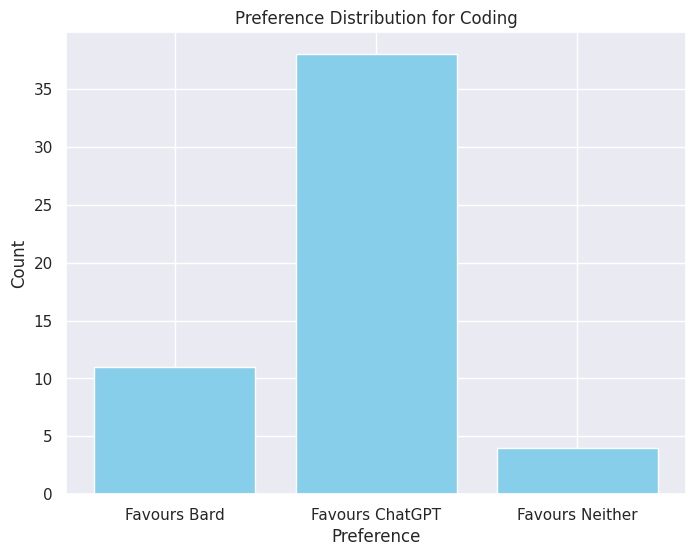

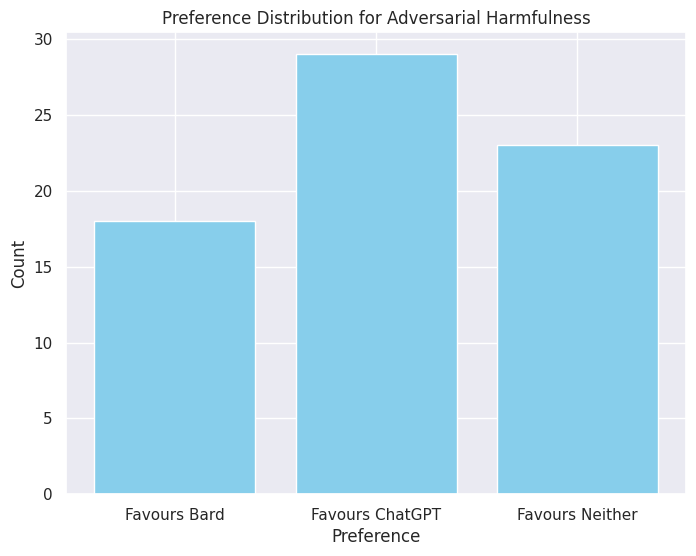

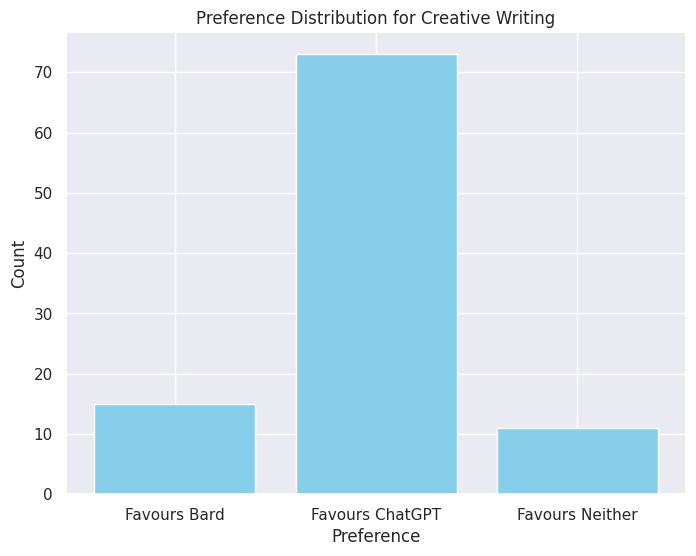

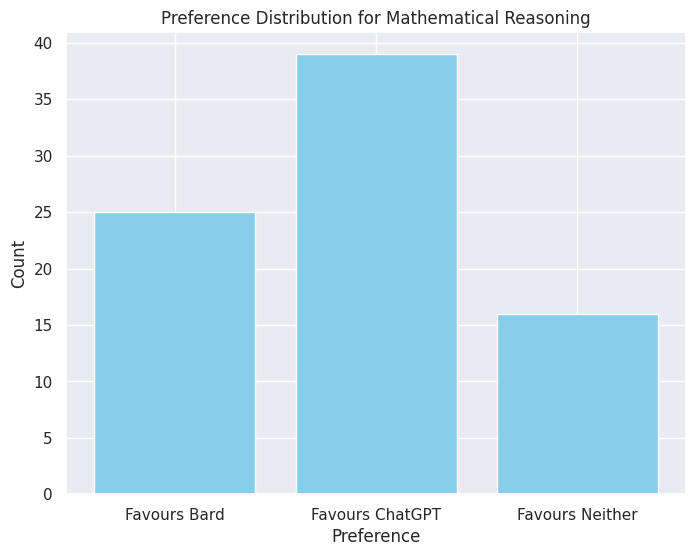

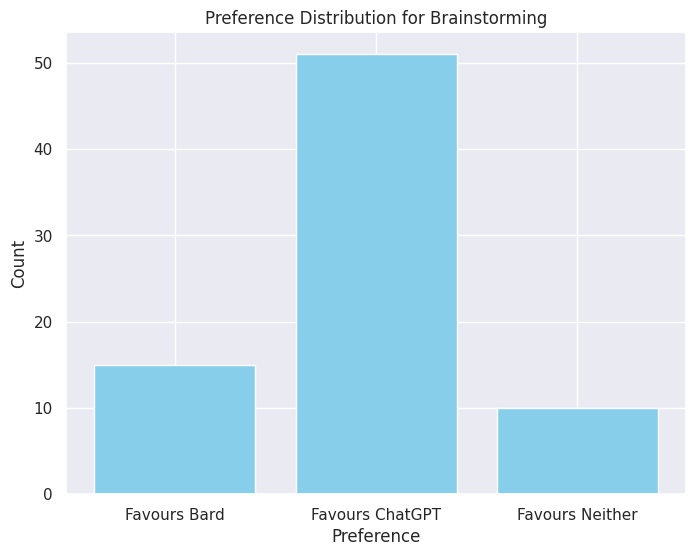

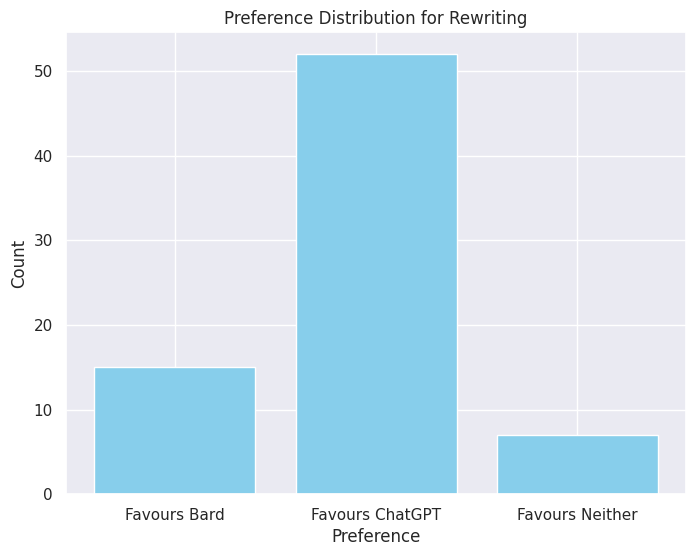

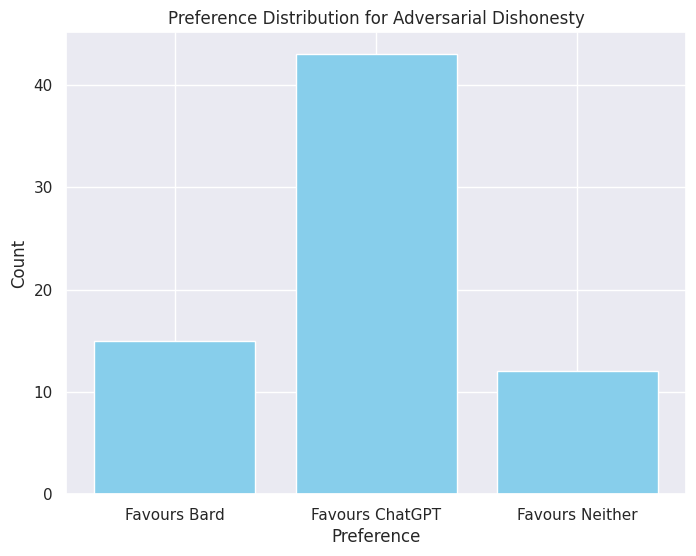

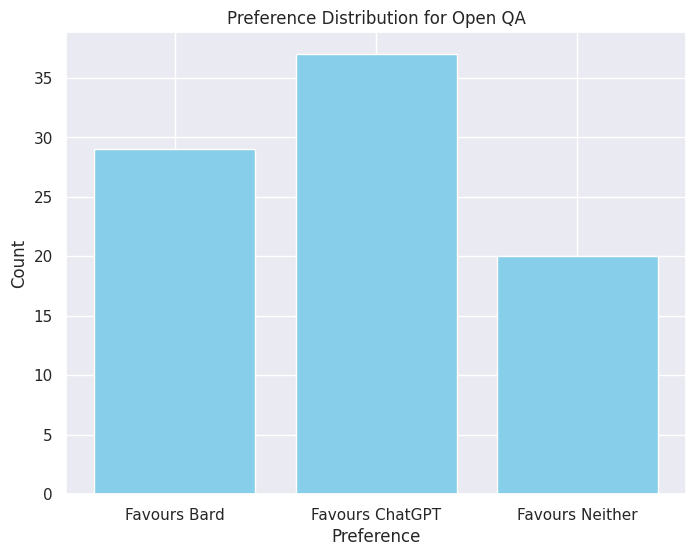

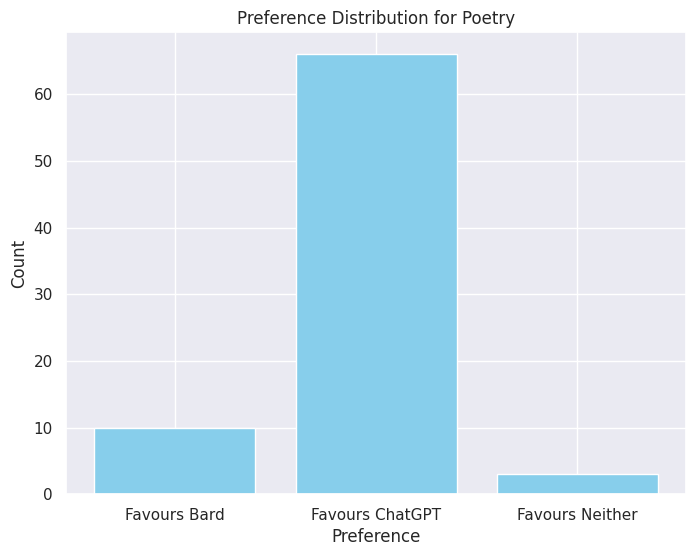

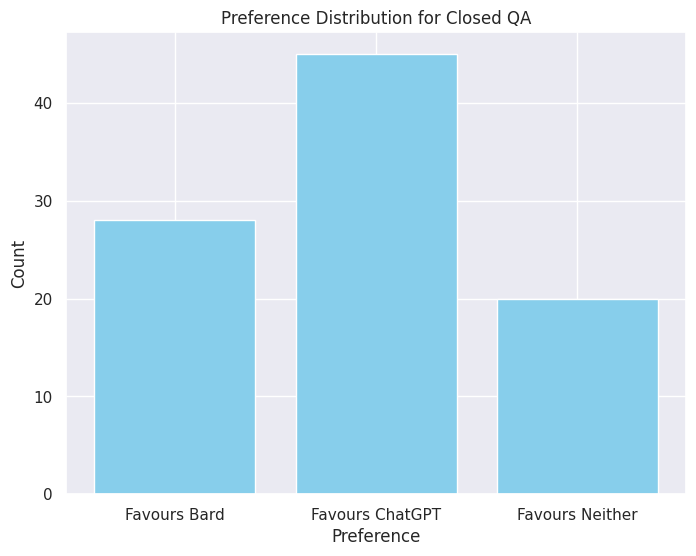

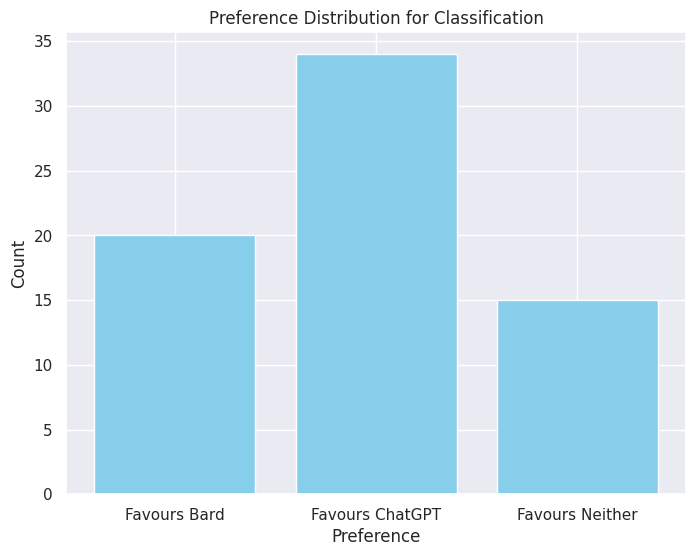

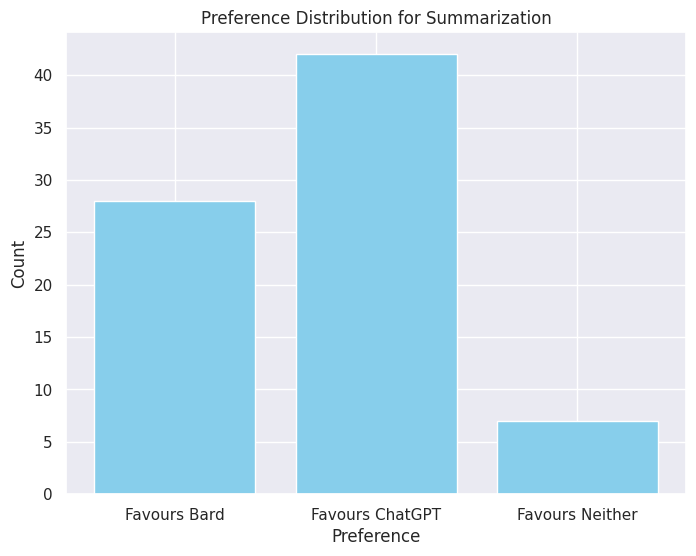

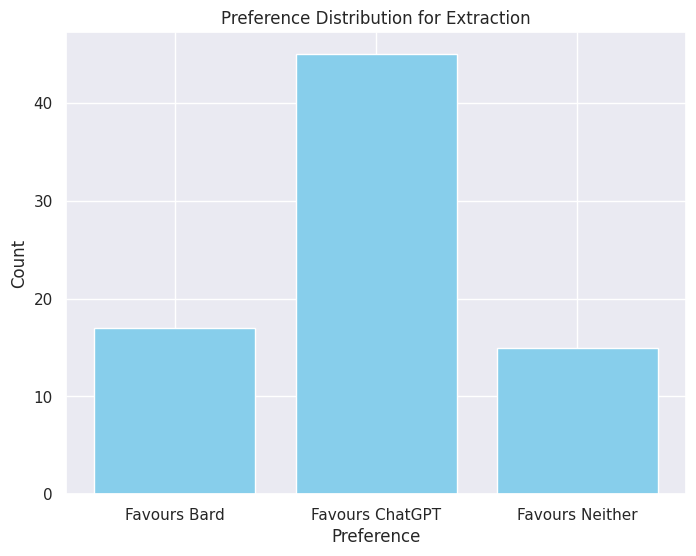

In [ ]:
for category, data in grouped_ratings.items():
    plt.figure(figsize=(8, 6))
    plt.bar(data['Rating'], data['Count'], color='skyblue')
    plt.title(f"Preference Distribution for {category}")
    plt.xlabel("Preference")
    plt.ylabel("Count")
    plt.xticks(data['Rating'])  # Ensure appropriate labels ('Favours Bard', etc.)
    plt.show()


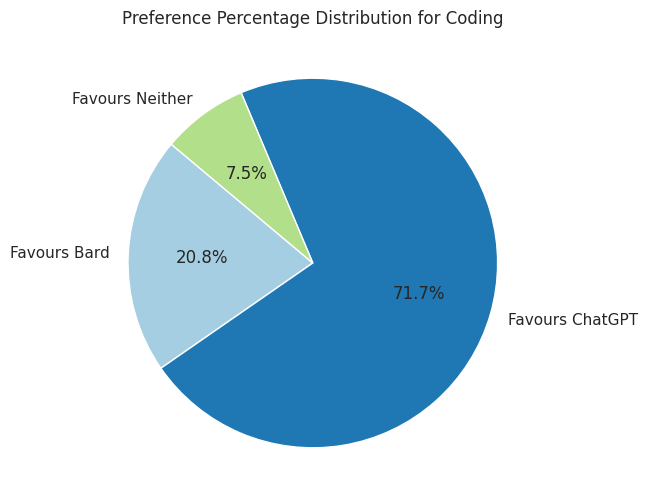

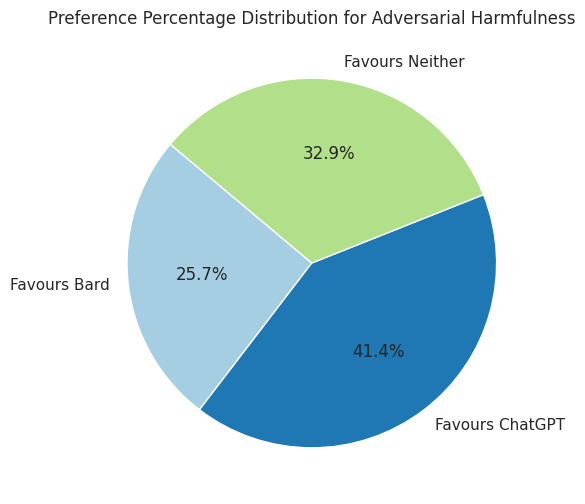

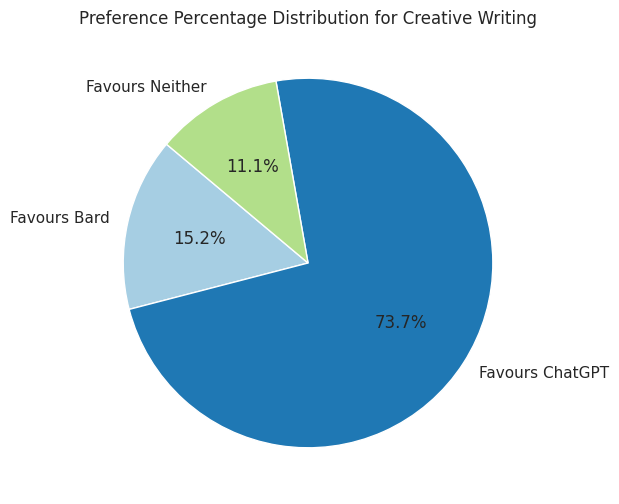

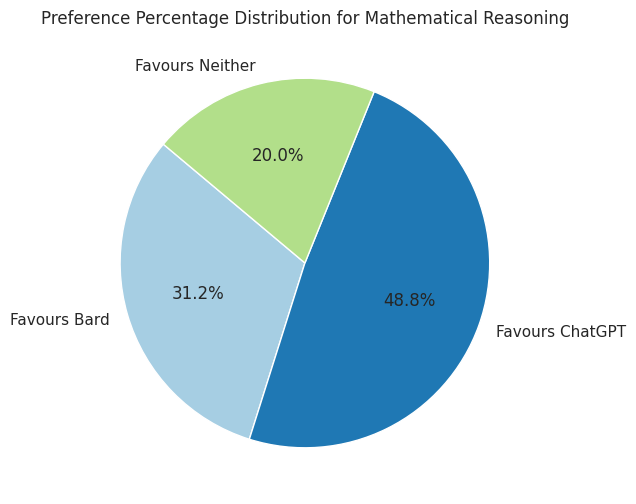

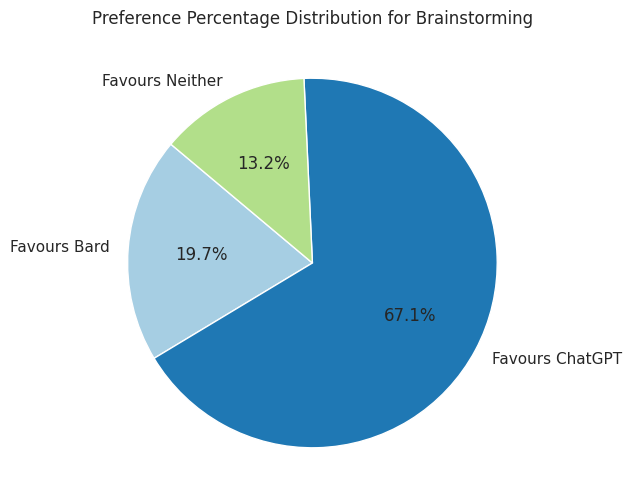

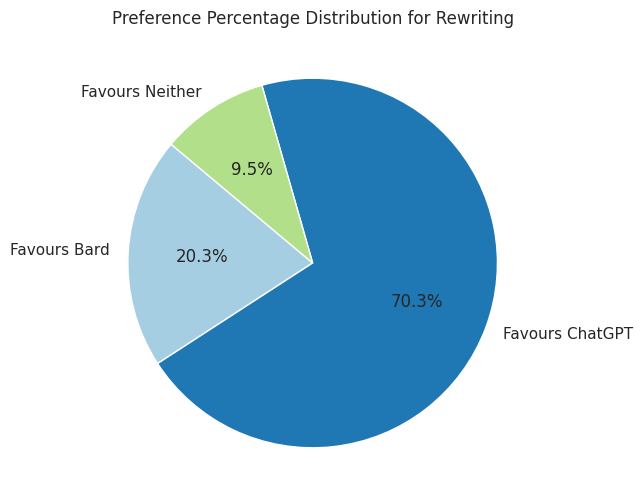

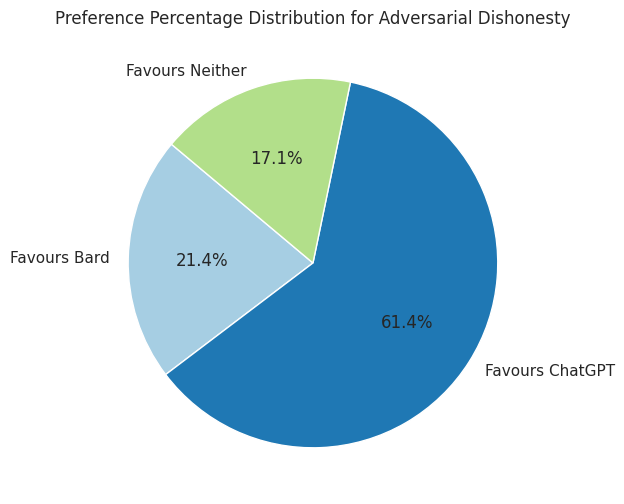

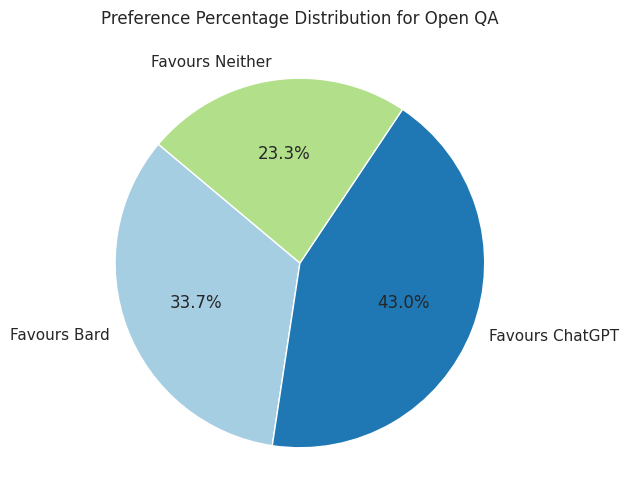

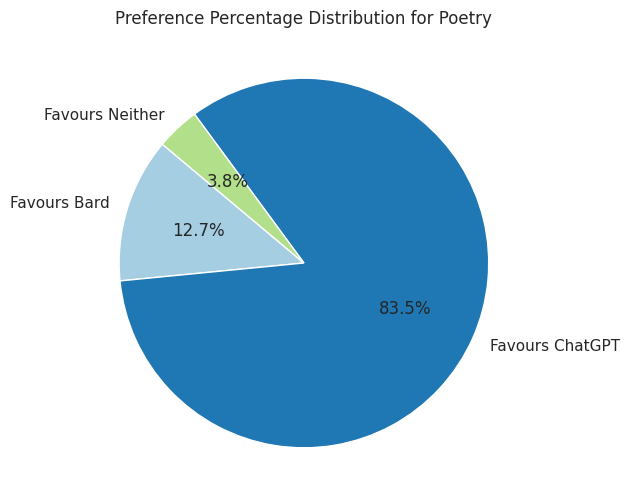

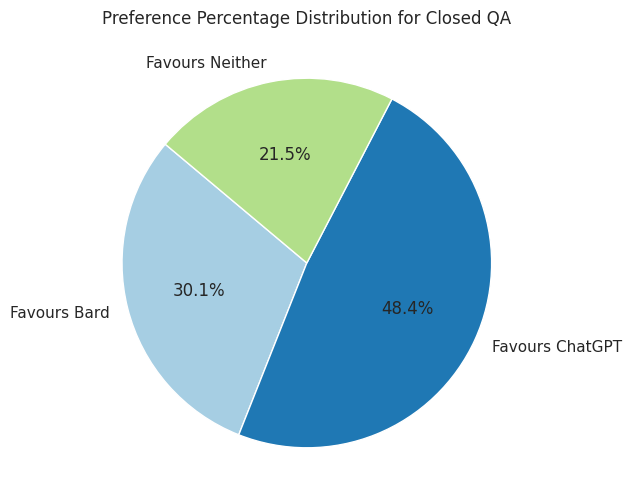

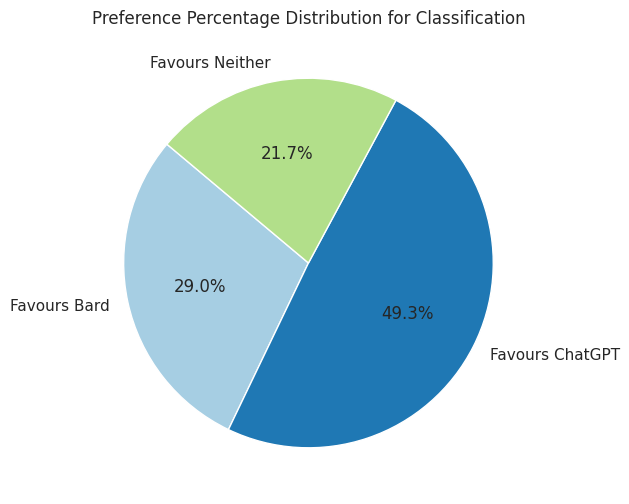

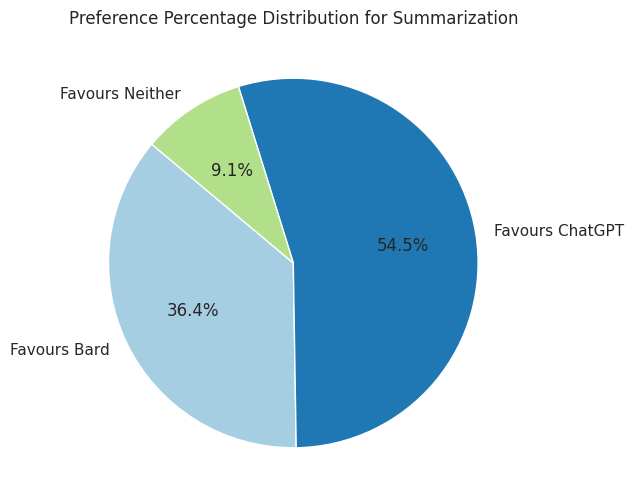

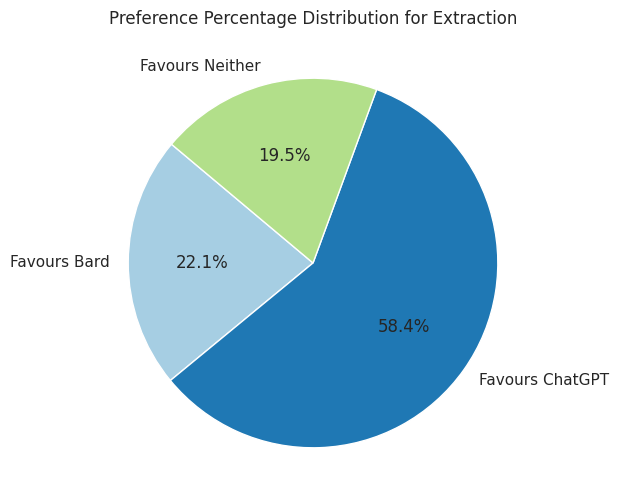

In [ ]:
for category, data in grouped_ratings.items():
    plt.figure(figsize=(6, 6))
    plt.pie(data['Count'], labels=data['Rating'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
    plt.title(f"Preference Percentage Distribution for {category}")
    plt.show()


In [ ]:
from IPython.display import display

# Granular Analysis
pd.set_option("display.max_colwidth", None)  # Displ
print(category_data['Coding'][category_data['Coding']['Rating'] == 7]['Prompt'].to_string())

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [ ]:
grouped_ratings

{'Coding':             Rating Percentage  Count
 0     Favours Bard     20.75%     11
 1  Favours ChatGPT     71.70%     38
 2  Favours Neither      7.55%      4,
 'Adversarial Harmfulness':             Rating Percentage  Count
 0     Favours Bard     25.71%     18
 1  Favours ChatGPT     41.43%     29
 2  Favours Neither     32.86%     23,
 'Creative Writing':             Rating Percentage  Count
 0     Favours Bard     15.15%     15
 1  Favours ChatGPT     73.74%     73
 2  Favours Neither     11.11%     11,
 'Mathematical Reasoning':             Rating Percentage  Count
 0     Favours Bard     31.25%     25
 1  Favours ChatGPT     48.75%     39
 2  Favours Neither     20.00%     16,
 'Brainstorming':             Rating Percentage  Count
 0     Favours Bard     19.74%     15
 1  Favours ChatGPT     67.11%     51
 2  Favours Neither     13.16%     10,
 'Rewriting':             Rating Percentage  Count
 0     Favours Bard     20.27%     15
 1  Favours ChatGPT     70.27%     52
 2  Favo

In [ ]:
for category, data in category_data.items():
    gpt_best = data[data['Rating'] == 7]
    bard_best = data[data['Rating'] == 1]
    gpt_best.to_csv(f'/content/Human Eval CSVs/{category}_gpt_best.csv', index=False)
    bard_best.to_csv(f'/content/Human Eval CSVs/{category}_bard_best.csv', index=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil

shutil.copytree('/content/Human Eval CSVs', '/content/drive/My Drive/Human_Eval_CSVs')

'/content/drive/My Drive/Human_Eval_CSVs'